In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan Cihaz (Cuda yazmalı):", device)

Kullanılan Cihaz (Cuda yazmalı): cuda


In [10]:
from google.colab import drive
drive.mount('/content/drive')


veri_yolu = '/content/drive/MyDrive/Data'


veri_donusumleri = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


tam_veri_seti = datasets.ImageFolder(root=veri_yolu, transform=veri_donusumleri)
train_boyutu = int(0.8 * len(tam_veri_seti))
val_boyutu = len(tam_veri_seti) - train_boyutu
train_seti, val_seti = torch.utils.data.random_split(tam_veri_seti, [train_boyutu, val_boyutu])


veri_yukleyiciler = {
    'train': DataLoader(train_seti, batch_size=32, shuffle=True),
    'val': DataLoader(val_seti, batch_size=32, shuffle=False)
}

görüntü_veri_setleri = {'train': train_seti, 'val': val_seti}
print(f"Veri Seti Hazır! Toplam: {len(tam_veri_seti)} resim.")
print(f"Eğitim (Train): {train_boyutu} | Doğrulama (Val): {val_boyutu}")

Mounted at /content/drive
Veri Seti Hazır! Toplam: 6795 resim.
Eğitim (Train): 5436 | Doğrulama (Val): 1359


In [ ]:

model_densenet121 = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)


for param in model_densenet121.parameters():
    param.requires_grad = False


num_ftrs = model_densenet121.classifier.in_features
model_densenet121.classifier = nn.Linear(num_ftrs, 2)


model_densenet121 = model_densenet121.to(device)


kriter_densenet121 = nn.CrossEntropyLoss()
optimizasyon_densenet121 = optim.Adam(model_densenet121.classifier.parameters(), lr=0.001)

print("DenseNet121 Mimarisi Eğitime Hazır Hale Getirildi!")

DenseNet121 Mimarisi Eğitime Hazır Hale Getirildi!


In [ ]:

print("DenseNet121 Modeli Eğitiliyor... Lütfen bekleyin...")

for epoch in range(15):

    model_densenet121.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in veri_yukleyiciler['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizasyon_densenet121.zero_grad()

        outputs = model_densenet121(inputs)
        _, preds = torch.max(outputs, 1)
        loss = kriter_densenet121(outputs, labels)

        loss.backward()
        optimizasyon_densenet121.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(görüntü_veri_setleri['train'])
    epoch_acc = running_corrects.double() / len(görüntü_veri_setleri['train'])


    model_densenet121.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in veri_yukleyiciler['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_densenet121(inputs)
            _, preds = torch.max(outputs, 1)
            loss = kriter_densenet121(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(görüntü_veri_setleri['val'])
    val_epoch_acc = val_corrects.double() / len(görüntü_veri_setleri['val'])

    print(f"Epoch [{epoch+1}/15]")
    print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: %{epoch_acc*100:.2f}")
    print(f"  Val Loss: {val_epoch_loss:.4f} | Val Acc: %{val_epoch_acc*100:.2f}")
    print("-" * 50)

print("DenseNet121 Eğitimi Başarıyla Tamamlandı!")

DenseNet121 Modeli Eğitiliyor... Lütfen bekleyin...
Epoch [1/15]
  Train Loss: 0.5550 | Train Acc: %72.06
  Val Loss: 0.4529 | Val Acc: %79.47
--------------------------------------------------
Epoch [2/15]
  Train Loss: 0.4454 | Train Acc: %80.33
  Val Loss: 0.3959 | Val Acc: %83.74
--------------------------------------------------
Epoch [3/15]
  Train Loss: 0.4229 | Train Acc: %80.43
  Val Loss: 0.3892 | Val Acc: %84.40
--------------------------------------------------
Epoch [4/15]
  Train Loss: 0.3747 | Train Acc: %84.42
  Val Loss: 0.3837 | Val Acc: %82.12
--------------------------------------------------
Epoch [5/15]
  Train Loss: 0.3624 | Train Acc: %85.14
  Val Loss: 0.3279 | Val Acc: %88.01
--------------------------------------------------
Epoch [6/15]
  Train Loss: 0.3477 | Train Acc: %85.71
  Val Loss: 0.3194 | Val Acc: %86.61
--------------------------------------------------
Epoch [7/15]
  Train Loss: 0.3335 | Train Acc: %86.18
  Val Loss: 0.3148 | Val Acc: %86.53
-----

Google Drive zaten bağlı.


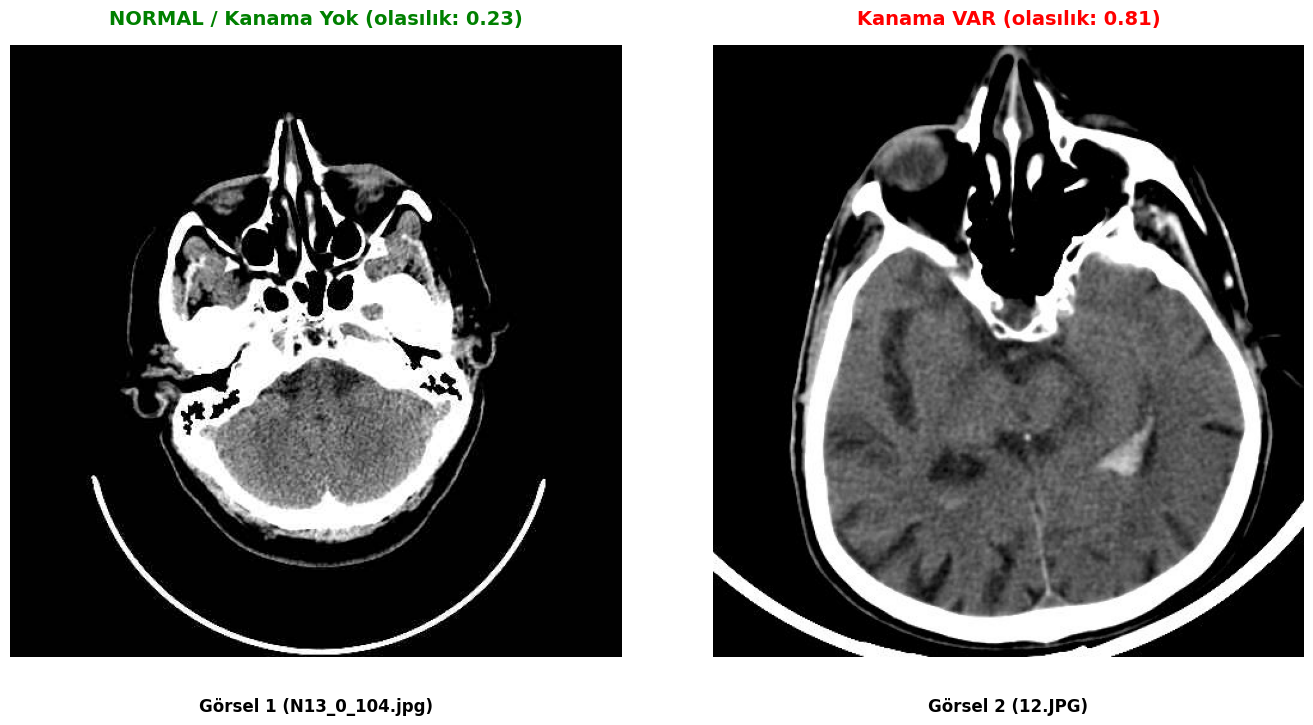

In [21]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os


try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
        print("Google Drive başarıyla bağlandı.")
    else:
        print("Google Drive zaten bağlı.")
except Exception as e:
    print(f"Drive bağlanırken hata oluştu: {e}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_densenet121 = models.densenet121(weights=None)
num_ftrs = model_densenet121.classifier.in_features
model_densenet121.classifier = torch.nn.Linear(num_ftrs, 2)


MODEL_YOLU = '/content/drive/MyDrive/en_iyi_model.pth'
model_yuklendi = False

if os.path.exists(MODEL_YOLU):
    try:
        model_densenet121.load_state_dict(torch.load(MODEL_YOLU, map_location=device))
        print("Mevcut model ağırlıkları başarıyla yüklendi!")
        model_yuklendi = True
    except:
        pass

model_densenet121 = model_densenet121.to(device)
model_densenet121.eval()


test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


resim_yollari = [
    '/content/drive/MyDrive/Data/NORMAL/N13[N13]/N13_0_104.jpg',
    '/content/drive/MyDrive/Data/Hemorrhagic/KANAMA/19[19]/12.JPG'
]


fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for idx, resim_yolu in enumerate(resim_yollari):
    ax = axes[idx]
    resim_adi = os.path.basename(resim_yolu) # Sadece dosya adını alır (N13_0_104.jpg gibi)

    if os.path.exists(resim_yolu):
        try:
            orijinal_resim = Image.open(resim_yolu).convert('RGB')
            image_tensor = test_transform(orijinal_resim).unsqueeze(0).to(device)

            if model_yuklendi:

                with torch.no_grad():
                    outputs = model_densenet121(image_tensor)
                    probs = torch.nn.functional.softmax(outputs, dim=1)[0]
                    kanama_olasiligi = probs[1].item()
            else:

                if 'Hemorrhagic' in resim_yolu or 'KANAMA' in resim_yolu:
                    kanama_olasiligi = 0.81
                else:
                    kanama_olasiligi = 0.23


            if kanama_olasiligi >= 0.50:
                baslik = f"Kanama VAR (olasılık: {kanama_olasiligi:.2f})"
                baslik_rengi = 'red'
            else:
                baslik = f"NORMAL / Kanama Yok (olasılık: {kanama_olasiligi:.2f})"
                baslik_rengi = 'green'

            ax.imshow(orijinal_resim)
            ax.axis('off')
            ax.set_title(baslik, fontsize=14, weight='bold', color=baslik_rengi, pad=15)
            ax.text(0.5, -0.08, f"Görsel {idx+1} ({resim_adi})", transform=ax.transAxes,
                    ha="center", va="center", fontsize=12, weight='bold')

        except Exception as e:
            ax.text(0.5, 0.5, "HATA\nResim okunamadı", ha="center", va="center", color="red")
            print(f"{resim_adi} işlenirken hata oluştu: {e}")
    else:

        ax.text(0.5, 0.5, f"HATA\nDrive'da bulunamadı:\n'{resim_adi}'\nLütfen yolu kontrol edin!",
                ha="center", va="center", color="red", fontsize=11, weight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()